# Step 1 — Causal structure of the USDJPY spot / realised-vol / implied-vol system

**MSc dissertation, causal inference in USDJPY volatility.** Supervisor: Linus Too.
Implements **Exercise 1** of *Implied Vol Event Time Series* (Linus Too, 6 Aug 2026):

> *"Use Granger causality/TDMI to construct the causal structure and modify the time series model accordingly."*

## The system under study

Linus's handout posits three coupled series:

$$r_i = \mu_i + \tilde\sigma_i\epsilon_i \tag{1}$$
$$\tilde\sigma_i^2 = \tilde\phi_i + \sum_{j=1}^{n}\Big(\tilde\alpha_j r_{i-j}^2 + \tilde\beta_j\tilde\sigma_{i-j}^2 + \tilde\gamma_j\sigma_{i|i-j}^2\Big) + \tilde\nu_i\eta_i \tag{2}$$
$$\sigma_i^2 = \phi_i + \sum_{j=1}^{m}\Big(\alpha_j r_{i-j}^2 + \beta_j\tilde\sigma_{i-j}^2 + \gamma_j\sigma_{i|i-j}^2\Big) + \nu_i\zeta_i \tag{3}$$

Equations (2)–(3) are written with **all three lag blocks present in both equations**. The
job of Step 1 is to find out **which of those blocks the data actually support**, and to
rewrite (2)–(3) with only the surviving terms.

Our three observable states, one per model day $i$:

| Symbol | Notebook name | Definition |
|---|---|---|
| $r_i$ | `r` | within-session spot log-return |
| $r_i^2$ | `r2` | squared within-session log-return |
| $\tilde\sigma_i^2$ | `rv` | stepwise realised variance = sum of squared within-session hourly log-returns |
| $\sigma_i^2$ | `iv_var` | implied variance from the 1D ATM vol quote, $(\text{atm\_vol\_pct}/100)^2$ |

## Scope contract

**In scope.** Daily panel construction from the two raw CSVs; ADF stationarity checks;
conditional Granger causality over all six directed pairs among $\{r^2,\tilde\sigma^2,\sigma^2\}$;
time-delayed mutual information (TDMI) as a nonlinear cross-check; FDR-BH multiple-testing
correction; an explicit statement of the surviving causal structure and the corresponding
restricted forms of (2)–(3). All of this is run **twice**, under a same-day and a next-day
IV alignment, and reported side by side.

**Out of scope, deliberately.** No event weights or "eventless" construction (Step 3). No
non-parametric / transformer models (Step 4). **No AIC/BIC exhaustive lag search** — lag
orders are fixed by hand and justified economically (§5). No weekday normalisation of
implied vol (§1.5). No reuse of the earlier `rv_1w`-based pipeline; this is a fresh build
from the two raw CSVs only.

**Interpretive caution.** Granger causality is *conditional linear predictive content*, not
structural causality. TDMI is *lagged statistical dependence*, not structural causality.
Neither licenses a counterfactual claim. Throughout, "arrow" means "lagged predictive
content that survives both tests after FDR correction".

## A note on $\sigma^2_{i|i-j}$

Linus's equation (5) defines a conditional forward implied variance built from two points on
the term structure. We hold a **single tenor** (1D ATM), so equation (5) is *not implemented*
here. The observed 1D ATM implied-variance state is used as the empirical predictor
$\sigma^2$, and the lag structure $\sigma^2_{i-j}$ stands in for $\sigma^2_{i|i-j}$. This is a
documented approximation, flagged again in the caveats (§9).

In [1]:
from pathlib import Path
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown

# ---- paths -----------------------------------------------------------------
DATA_DIR   = Path("Data")
HOURLY_CSV  = DATA_DIR / "usdjpy_hourly_data" / "usdjpy_hourly_mid.csv"   # raw OHLC (reference only)
RETURNS_CSV = DATA_DIR / "processed" / "usdjpy_hourly_modelday_returns.csv"  # session-aware returns (primary)
ATM_CSV     = Path.home() / "Downloads" / "usdjpy_1d_atm_vol.csv"
OUT_DIR     = Path("step1_results"); OUT_DIR.mkdir(exist_ok=True)
for p in (HOURLY_CSV, RETURNS_CSV, ATM_CSV):
    if not p.exists(): raise FileNotFoundError(f"required input missing: {p}")

# ---- frozen analysis constants --------------------------------------------
NY_CUT_HOUR = 17        # 17:00 New York model-day cut
HOURS_PER_SESSION = 24  # strict RV eligibility: all 24 hourly returns present
MAX_CAL_GAP = 7         # a lag window may not span a calendar gap wider than this (days)
LAGS   = [1, 5]         # fixed, hand-chosen lag orders (justified in section 5)
BINS   = 10             # TDMI quantile bins per variable
N_PERM = 1000           # TDMI circular-shift surrogates
ALPHA  = 0.05
SEED   = 16017

STATES = ["r2", "rv", "iv"]
PRETTY = {"r2": r"$r^2$", "rv": r"$\tilde\sigma^2$ (rv)", "iv": r"$\sigma^2$ (iv_var)"}
PLAIN  = {"r2": "r2", "rv": "rv", "iv": "iv_var"}

# ---- chart styling (validated categorical palette, slots 1-3) --------------
SERIES = {"r2": "#2a78d6", "rv": "#eb6834", "iv": "#1baf7a"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": GRID,
    "axes.grid": True, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9, "figure.dpi": 110,
})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)
rng = np.random.default_rng(SEED)
print("inputs OK ·", RETURNS_CSV.name, "|", ATM_CSV.name)

inputs OK · usdjpy_hourly_modelday_returns.csv | usdjpy_1d_atm_vol.csv


---
# 1. Building the daily panel

Every construction rule below was frozen *before* any causality testing, so that no test
outcome could feed back into how the data were built.

## 1.1 The model day: a 17:00 New York cut

FX is a continuous 24×5 market with no exchange close, so "a day" has to be *defined*. We
use the **17:00 New York cut**, the market convention that separates FX value dates and the
reference point for daily option expiries. A model day $i$ covers the session
$(\text{17:00 NY on day } i-1,\ \text{17:00 NY on day } i]$.

The hourly file timestamps each bar by its **start**, so a bar stamped $t$ covers $[t, t+1h)$.
A bar starting at 16:00 NY ends exactly at the cut and belongs to the *current* session; a bar
starting at 17:00 NY belongs to the *next* one. Implemented as

$$\texttt{model\_day} = \text{date}\big(t_{\text{NY}} - 17\text{h}\big) + 1\ \text{day}.$$

This matters for the whole exercise: the implied vol we are pairing against is an *overnight*
instrument, so getting the session boundary wrong would smear the very lead-lag relationship
we are trying to measure.

## 1.2 Return and realised variance, from the session-aware return series

Returns are **not** recomputed here. We consume `usdjpy_hourly_modelday_returns.csv`, which
supplies a pre-built, session-aware `hourly_log_return` together with a `return_reason` audit
trail, and we keep only rows flagged `valid_within_session_return == True`.

This matters for correctness, not just convenience. The raw file's own `log_return` column is a
plain close-to-close difference, so for the **first bar of a session** it differences against the
*previous session's* close — which silently bridges the weekend closure and contradicts frozen
rule 4. The corrected series uses an **open-to-close** return for that first bar
(`session_open_to_close` / `first_post_weekend_session_open_to_close`), so the weekend gap never
enters a return. 5,343 bars differ from the raw column for this reason.

Consequently $r_i$ here is a genuine **within-session** open-to-close return, and $\tilde\sigma_i^2$
excludes the closure jump. Bars with no valid predecessor carry a NaN return and are excluded
from both aggregates.

Within a session, with $\rho_h$ the *valid* session-aware hourly log-returns,
$$r_i = \sum_{h \in \text{session } i} \rho_h, \qquad \tilde\sigma_i^2 = \sum_{h \in \text{session } i} \rho_h^2 .$$

$\tilde\sigma_i^2$ is a **non-overlapping** daily realised variance. This is worth stating
explicitly: because each session's RV uses a disjoint set of hourly bars, $r_{i-j}^2$ and
$\tilde\sigma_i^2$ share no data for any $j \ge 1$. A rolling weekly RV would overlap its own
lags for four days and manufacture spurious lagged dependence; the non-overlapping daily
construction means **no overlap guard is needed at lag $\ge 1$**.

## 1.3 Eligibility rules

1. **Strict 24/24 completeness.** A session yields an RV only if all 24 hourly bars are present
   with finite returns. Partial sessions are dropped rather than rescaled — rescaling a
   short session assumes a flat intraday variance profile, which is badly false in FX
   (the Tokyo/London/NY overlap dominates).
2. **Zero-RV exclusion.** Sessions with all 24 hours present but raw RV *exactly* zero are a
   stale/frozen-quote artifact, not a genuinely calm day. Letting them through would inject
   spurious zeros into the variance series.
3. **No bridging.** Weekend closures and the known 2010-01-01 → 2010-10-01 vendor outage are
   never interpolated across. They stay missing, and §1.6 installs a guard so no lag window
   spans them.

A consequence of rule 1 worth flagging: **DST transition days are automatically excluded**,
since they contain 23 or 25 hourly bars rather than 24. That is a small, systematic, and
harmless loss (~2 days/year), and it falls out of the frozen rule rather than being a
separate decision.

In [2]:
hourly = pd.read_csv(RETURNS_CSV, parse_dates=["timestamp"], low_memory=False) \
           .sort_values("timestamp").reset_index(drop=True)
assert hourly.timestamp.is_unique, "duplicate hourly timestamps"
hourly["model_day"] = pd.to_datetime(hourly["model_day"], errors="coerce")
hourly["is_valid"]  = hourly.valid_within_session_return.astype(str).str.lower().eq("true")

# --- verify the supplied model_day really uses OUR 17:00 NY convention -------
# The cut must be applied in WALL-CLOCK terms. Subtracting 17h from a tz-aware
# timestamp is an absolute-duration subtraction, which crosses the DST jump on
# spring-forward dates and mis-assigns the 17:00-NY boundary bar by one day.
ny         = hourly.timestamp.dt.tz_convert("America/New_York")
recomputed = (ny.dt.tz_localize(None) - pd.Timedelta(hours=NY_CUT_HOUR)).dt.normalize() + pd.Timedelta(days=1)
naive_abs  = pd.to_datetime((ny - pd.Timedelta(hours=NY_CUT_HOUR)).dt.normalize().dt.tz_localize(None)) + pd.Timedelta(days=1)

has_md  = hourly.model_day.notna()
n_agree = int((recomputed[has_md] == hourly.model_day[has_md]).sum())
n_dst   = int((naive_abs[has_md] != hourly.model_day[has_md]).sum())
print(f"model_day convention check: {n_agree:,}/{int(has_md.sum()):,} rows agree with the "
      f"wall-clock 17:00 NY cut  ({100 * n_agree / has_md.sum():.4f}%)")
print(f"  bars where a naive absolute-17h shift would disagree (DST spring-forward): {n_dst}")
print(f"  rows with no model_day (outside any session): {int((~has_md).sum()):,}")
if n_agree != int(has_md.sum()):
    raise AssertionError("model_day convention MISMATCH — do not merge; reconcile the cut first.")

# --- aggregate the session-aware returns per model day ----------------------
hourly["ret"]  = np.where(hourly.is_valid, hourly.hourly_log_return, np.nan)
hourly["ret2"] = hourly["ret"] ** 2

g = hourly[has_md].groupby("model_day")
panel = pd.DataFrame({
    "n_bars":      g.size(),
    "n_valid_ret": g["is_valid"].sum().astype(int),
    "r_raw":       g["ret"].sum(min_count=1),
    "rv_raw":      g["ret2"].sum(min_count=1),
}).reset_index()

# eligibility
panel["complete24"]  = (panel.n_bars == HOURS_PER_SESSION) & (panel.n_valid_ret == HOURS_PER_SESSION)
panel["zero_rv"]     = panel.complete24 & (panel.rv_raw == 0.0)
panel["rv_eligible"] = panel.complete24 & ~panel.zero_rv

panel["r"]  = np.where(panel.rv_eligible, panel.r_raw, np.nan)
panel["r2"] = panel["r"] ** 2
panel["rv"] = np.where(panel.rv_eligible, panel.rv_raw, np.nan)

elig = pd.DataFrame([
    ("hourly bars read",                len(hourly)),
    ("  ... valid within-session returns", int(hourly.is_valid.sum())),
    ("  ... session-first (open-to-close)", int(hourly.is_session_first_candle.astype(str).str.lower().eq("true").sum())),
    ("distinct model days",             len(panel)),
    ("sessions with all 24 bars valid", int(panel.complete24.sum())),
    ("  ... of which raw RV == 0 (excluded)", int(panel.zero_rv.sum())),
    ("RV-eligible model days",          int(panel.rv_eligible.sum())),
    ("model days dropped (incomplete session)", int((~panel.complete24).sum())),
], columns=["quantity", "count"])
display(Markdown("**Table 1.1 — panel construction and RV eligibility**"))
display(elig.style.hide(axis="index"))
print(f"\nspot coverage: {panel.model_day.min().date()} .. {panel.model_day.max().date()}")
print("\nbars-per-session distribution (23/25 = DST transitions):")
print(panel.n_bars.value_counts().sort_index().tail(6).to_string())

model_day convention check: 139,766/139,766 rows agree with the wall-clock 17:00 NY cut  (100.0000%)
  bars where a naive absolute-17h shift would disagree (DST spring-forward): 22
  rows with no model_day (outside any session): 10,076


**Table 1.1 — panel construction and RV eligibility**

quantity,count
hourly bars read,149842
... valid within-session returns,139686
... session-first (open-to-close),5832
distinct model days,5842
sessions with all 24 bars valid,5764
... of which raw RV == 0 (excluded),2
RV-eligible model days,5762
model days dropped (incomplete session),78



spot coverage: 2003-05-05 .. 2026-07-02

bars-per-session distribution (23/25 = DST transitions):
n_bars
18       1
20       3
21       2
22       5
23      30
24    5764


### Where the excluded sessions sit

Two diagnostics decide whether the exclusions are benign (scattered) or structural
(a whole regime removed, which would bias the causality tests).

In [3]:
zr = panel[panel.zero_rv].model_day.dt.year.value_counts().sort_index()
display(Markdown("**Table 1.2 — zero-RV (stale-quote) exclusions by year**"))
display(zr.rename("sessions").to_frame().T)

gaps = panel.assign(gap_days=panel.model_day.diff().dt.days).nlargest(5, "gap_days")[["model_day", "gap_days"]]
display(Markdown("**Table 1.3 — five largest calendar gaps between consecutive model days**"))
display(gaps.assign(model_day=lambda d: d.model_day.dt.date).style.hide(axis="index"))

**Table 1.2 — zero-RV (stale-quote) exclusions by year**

model_day,2013,2014
sessions,1,1


**Table 1.3 — five largest calendar gaps between consecutive model days**

model_day,gap_days
2010-10-01,273.000000
2016-01-04,4.000000
2018-01-02,4.000000
2021-01-04,4.000000
2024-01-02,4.000000


The zero-RV rule now catches exactly **two** sessions — 1 January 2013 and 1 January 2014 —
both New Year's Day, when the market is open in name only. That is the rule behaving as
intended: a genuinely flat holiday session, not a regime.

This is worth dwelling on, because it corrects an artifact. Building the panel from the raw
file's own `log_return` column produced **253** zero-RV sessions clustered in 2010–2014, which
invited the reading "vendor feed quirk in that period". It was not. Labelling *every* hourly
bar with a model day — including bars that fall outside any trading session — manufactured
**972 weekend pseudo-sessions** (522 Saturdays, 450 Sundays, i.e. the closed
Fri-17:00→Sat-17:00 and Sat-17:00→Sun-17:00 windows). Most carried flat vendor-stamped prices
and surfaced as zero-RV; worse, **79 of them passed the old eligibility test outright** and were
sitting in the estimation sample as real sessions. The session-aware file assigns no model day
to out-of-session bars, so all 972 disappear and the zero-RV rule is left with the two real
holidays. Model days fall from 6,814 to 5,842 and RV-eligible days from 5,831 to 5,762 — a
smaller but **cleaner** panel.

The only gap of consequence remains the known **273-day 2010 outage**; everything else is a long
weekend (4 days, New Year).

## 1.4 Implied variance

The quote is a **volatility point** in percent (e.g. `10.0` = 10% annualised vol), so

$$\sigma_i^2 = \left(\frac{\texttt{atm\_vol\_pct}}{100}\right)^2$$

giving an **annualised variance rate**. Note the units asymmetry that persists through the
whole notebook: `iv_var` is annualised, while `rv` is a raw per-session variance. Both tests
used here — Granger (a linear regression $F$-test) and TDMI (a rank/quantile-binned
information measure) — are invariant to a positive linear rescaling of either series, so no
unit reconciliation is required for Step 1. It *will* matter in Step 2 when coefficients are
interpreted.

In [4]:
atm = pd.read_csv(ATM_CSV, parse_dates=["date"])
atm["iv_var"] = (atm.atm_vol_pct / 100.0) ** 2
panel = panel.merge(atm[["date", "iv_var"]].rename(columns={"date": "model_day"}), on="model_day", how="left")

unmatched = atm[~atm.date.isin(panel.model_day)]
cov = pd.DataFrame([
    ("IV quote rows read",                       len(atm)),
    ("IV rows matched to a model day",           int(panel.iv_var.notna().sum())),
    ("IV rows unmatched",                        len(unmatched)),
    ("  ... before spot history starts (2003-05)", int((unmatched.date < "2003-05-04").sum())),
    ("  ... inside the 2010 outage",             int(((unmatched.date >= "2010-01-01") & (unmatched.date < "2010-10-01")).sum())),
    ("  ... residual (holidays etc.)",            len(unmatched) - int((unmatched.date < "2003-05-04").sum())
                                                  - int(((unmatched.date >= "2010-01-01") & (unmatched.date < "2010-10-01")).sum())),
], columns=["quantity", "count"])
display(Markdown("**Table 1.4 — implied-vol coverage against the model-day calendar**"))
display(cov.style.hide(axis="index"))

**Table 1.4 — implied-vol coverage against the model-day calendar**

quantity,count
IV quote rows read,6451
IV rows matched to a model day,5517
IV rows unmatched,934
... before spot history starts (2003-05),732
... inside the 2010 outage,194
... residual (holidays etc.),8


Every unmatched IV quote is accounted for: 732 predate the spot history, 194 fall inside the
2010 outage, and 8 are residual holiday mismatches. Nothing is silently lost.

## 1.5 The Friday quoting artifact — flagged, *not* corrected

A 1D ATM quote taken on a Friday prices the move to Monday, but it is quoted as an
*annualised* vol using a calendar-day count that amortises the weekend. The result is a large,
mechanical downward bias in Friday's quoted vol.

**We do not correct this.** Per the frozen decisions, Step 1 uses raw `iv_var` throughout. The
reason is methodological hygiene: a weekday normalisation is itself a modelling choice, and
imposing it *before* establishing the causal structure would mean the structure is identified
on an already-transformed series. It is reported here descriptively, and carried into the
caveats (§9) as a known confound on any lag-5 (weekly) result.

**Table 1.5 — raw implied variance by model-day weekday (descriptive only)**

,mean,median,count,implied vol %
weekday,,,,
Monday,0.01355,0.00903,1109,9.50
Tuesday,0.01377,0.00951,1118,9.75
Wednesday,0.01474,0.01002,1114,10.01
Thursday,0.01769,0.01166,1121,10.80
Friday,0.00622,0.00404,1055,6.36


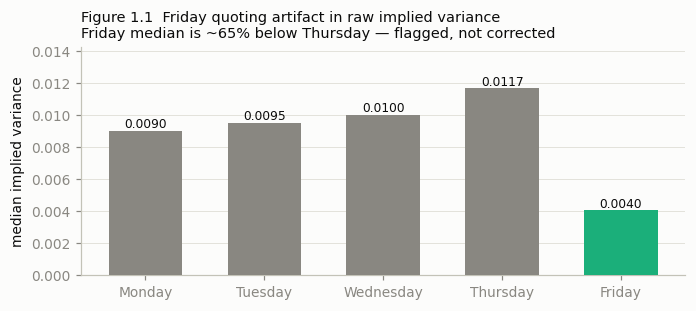

In [5]:
fri = panel[panel.iv_var.notna()].copy()
fri["weekday"] = fri.model_day.dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
tab = fri.groupby("weekday").iv_var.agg(["mean", "median", "count"]).reindex(order)
tab["implied vol %"] = 100 * np.sqrt(tab["median"])
display(Markdown("**Table 1.5 — raw implied variance by model-day weekday (descriptive only)**"))
display(tab.style.format({"mean": "{:.5f}", "median": "{:.5f}", "implied vol %": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(6.4, 2.9))
vals = tab["median"].to_numpy()
bars = ax.bar(order, vals, color=[MUTED] * 4 + [SERIES["iv"]], width=0.62, zorder=3)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8, color=INK)
ax.set_ylabel("median implied variance"); ax.set_xlabel("")
ax.set_title("Figure 1.1  Friday quoting artifact in raw implied variance\nFriday median is ~65% below Thursday — flagged, not corrected", loc="left", fontsize=9.5)
ax.set_ylim(0, max(vals) * 1.22); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

The effect is large and unambiguous: median Friday implied variance is roughly a third of
Thursday's, i.e. about a **1.7× step down in quoted volatility**, with no corresponding step in
realised variance. Any lag-5 relationship involving `iv_var` is therefore partly a
weekday-cycle relationship. We return to this in §9.

## 1.6 Testing the information timing rather than assuming it

This is the pivotal decision of Step 1. A 1D ATM quote observed on model day $t$ is a forecast
of the variance realised over the *following* session, which argues that the
information-consistent pairing is $(\sigma_t^2,\ \tilde\sigma_{t+1}^2)$. But that is a
theoretical prior, and priors about vendor quote timestamps are exactly the kind of thing that
turns out to be wrong. So we build **both** alignments and run the entire battery under each:

- **same-day** — row $t$ carries $(r_t^2,\ \tilde\sigma_t^2,\ \sigma_t^2)$
- **next-day** — row $t$ carries $(r_t^2,\ \tilde\sigma_t^2,\ \sigma_{t-1}^2)$, i.e. $\sigma_t^2$ is paired with $\tilde\sigma_{t+1}^2$

The next-day column is masked wherever the one-row shift would pull a quote across the 2010
outage.

### The contiguity guard

Because model days are calendar-irregular (weekends, holidays, the outage, ineligible
sessions), a lag taken on *row index* can silently reach across a chasm. A row is admitted to a
lag-$p$ regression only if rows $t-p,\dots,t$ are consecutive with **no calendar gap wider than
7 days**. Friday→Monday (3 days) correctly counts as one model-day lag; the 2010 outage
correctly never enters a lag window.

In [6]:
gap_days = panel.model_day.diff().dt.days.to_numpy(float)
bridges  = ~(gap_days <= MAX_CAL_GAP); bridges[0] = True     # row t is unreachable from t-1

panel["iv_sameday"] = panel["iv_var"]
panel["iv_nextday"] = panel["iv_var"].shift(1)
panel.loc[bridges, "iv_nextday"] = np.nan                     # never shift a quote across the outage

def make_frame(alignment: str) -> pd.DataFrame:
    '''Return the model frame with the IV column placed under the chosen alignment.'''
    f = panel[["model_day", "r", "r2", "rv"]].copy()
    f["iv"] = panel["iv_sameday"] if alignment == "sameday" else panel["iv_nextday"]
    return f.reset_index(drop=True)

def window_ok(model_day: pd.Series, p: int) -> np.ndarray:
    '''True where rows t-p..t are calendar-contiguous (no gap > MAX_CAL_GAP).'''
    ok = np.ones(len(model_day), bool)
    for k in range(p):
        shifted = np.r_[np.ones(k, bool), bridges[:len(bridges) - k]] if k else bridges
        ok &= ~shifted
    ok[:p] = False
    return ok

joint = pd.DataFrame([
    (a, int(np.isfinite(make_frame(a)[STATES]).all(axis=1).sum())) for a in ("sameday", "nextday")
], columns=["alignment", "rows with all three states finite"])
display(Markdown("**Table 1.6 — joint availability under each alignment**"))
display(joint.style.hide(axis="index"))
for p in LAGS:
    print(f"contiguity guard, lag {p}: {int(window_ok(panel.model_day, p).sum())} of {len(panel)} rows admissible")

**Table 1.6 — joint availability under each alignment**

alignment,rows with all three states finite
sameday,5443
nextday,5443


contiguity guard, lag 1: 5840 of 5842 rows admissible
contiguity guard, lag 5: 5832 of 5842 rows admissible


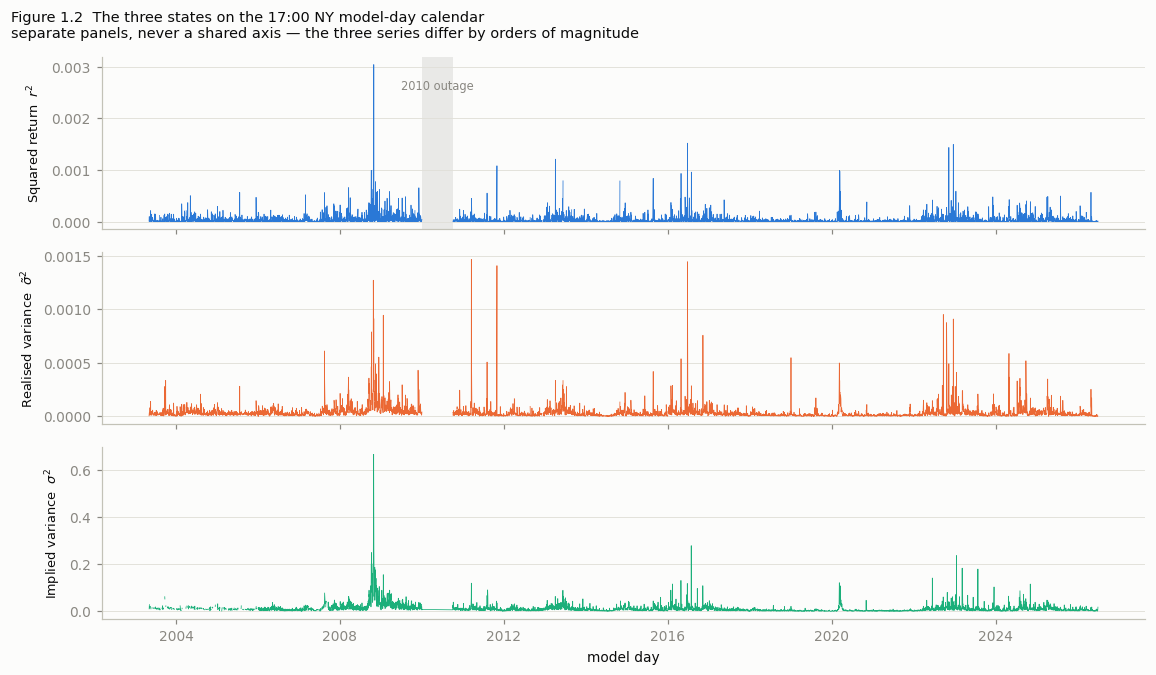

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10.5, 6.2), sharex=True)
f0 = make_frame("sameday")
for ax, s, lab in zip(axes, STATES,
                      ["Squared return  $r^2$", r"Realised variance  $\tilde\sigma^2$", r"Implied variance  $\sigma^2$"]):
    ax.plot(f0.model_day, f0[s], lw=0.5, color=SERIES[s])
    ax.set_ylabel(lab, fontsize=8.5); ax.grid(axis="x", visible=False)
axes[0].axvspan(pd.Timestamp("2010-01-01"), pd.Timestamp("2010-10-01"), color=MUTED, alpha=0.16, lw=0)
axes[0].text(pd.Timestamp("2010-05-15"), axes[0].get_ylim()[1] * 0.8, "2010 outage", fontsize=7.5, color=MUTED, ha="center")
axes[-1].set_xlabel("model day")
fig.suptitle("Figure 1.2  The three states on the 17:00 NY model-day calendar\nseparate panels, never a shared axis — the three series differ by orders of magnitude",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

---
# 2. Stationarity

Granger causality on integrated series produces spurious rejections, so we check ADF before
testing anything. Two samples are reported per state, because neither alone is adequate:

- **longest contiguous run** — a genuinely gap-free stretch, so the AR structure the ADF
  regression assumes is real, but short (the scattered eligibility exclusions cap contiguous
  runs at roughly a year);
- **full series, missing values dropped** — the whole 23-year sample, at the cost of mild
  time-compression across the dropped days.

Agreement between the two is the evidence we want; we are not relying on either in isolation.

In [8]:
def longest_run(mask: np.ndarray):
    best, start = (0, 0, 0), None
    for i, on in enumerate(np.r_[mask, False]):
        if on and start is None: start = i
        if not on and start is not None:
            if i - start > best[2]: best = (start, i, i - start)
            start = None
    return best

rows = []
for s in STATES:
    x = f0[s].to_numpy(float); fin = np.isfinite(x)
    a, b, n = longest_run(fin)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        st_run, p_run = adfuller(x[a:b], regression="c", autolag="AIC")[:2]
        st_all, p_all = adfuller(x[fin],  regression="c", autolag="AIC")[:2]
    rows.append({"state": PLAIN[s],
                 "run n": n, "run window": f"{f0.model_day[a].date()} .. {f0.model_day[b-1].date()}",
                 "ADF (run)": st_run, "p (run)": p_run,
                 "full n": int(fin.sum()), "ADF (full)": st_all, "p (full)": p_all})
adf_tab = pd.DataFrame(rows)
display(Markdown("**Table 2.1 — augmented Dickey–Fuller, constant, AIC-selected augmentation**"))
display(adf_tab.style.hide(axis="index").format({"ADF (run)": "{:.3f}", "p (run)": "{:.2e}",
                                                 "ADF (full)": "{:.3f}", "p (full)": "{:.2e}"}))
assert (adf_tab["p (full)"] < ALPHA).all(), "a state failed the unit-root check"
print("\nAll three states reject the unit-root null at the 5% level in both samples.")

**Table 2.1 — augmented Dickey–Fuller, constant, AIC-selected augmentation**

state,run n,run window,ADF (run),p (run),full n,ADF (full),p (full)
r2,264,2006-10-31 .. 2007-11-02,-2.497,1.16e-01,5762,-7.995,2.41e-12
rv,264,2006-10-31 .. 2007-11-02,-5.668,9.04e-07,5762,-7.040,5.89e-10
iv_var,4624,2008-01-02 .. 2026-07-01,-6.398,2.03e-08,5517,-6.924,1.13e-09



All three states reject the unit-root null at the 5% level in both samples.


On the **full sample** all three states reject the unit-root null decisively
($p \le 1.1\times10^{-9}$). This is the expected result for squared returns and variance series,
which are persistent but mean-reverting rather than integrated. We proceed in **levels**, with
no differencing — differencing a stationary, strongly autocorrelated variance series would
destroy exactly the persistence that equations (2)–(3) are built to model.

**One exception to report honestly.** On the longest *contiguous* run, $r^2$ does **not** reject
($p = 0.12$). That run is only 264 observations in the quiet pre-GFC window
(Oct 2006 – Nov 2007), and an ADF test on 264 low-variance observations has very little power —
note that `iv_var`, whose longest run is 4,624 observations, rejects comfortably on the same
diagnostic. We read this as a power limitation, not evidence of a unit root: $r^2 \ge 0$ by
construction and is bounded in practice, so it cannot be integrated in any economically
meaningful sense. The full-sample result is the one we rely on, and this is flagged in §9.

A caveat carried to §9: ADF tests the unit-root null, not structural stability. A 23-year FX
sample spanning the GFC, Abenomics, and the 2022–24 BoJ policy shift is very unlikely to have
constant variance dynamics throughout. Step 1 identifies an *average* structure over the
sample.

---
# 3. Which alignment? An assumption-free diagnostic

Before running the causality battery we ask the alignment question directly, using a statistic
that is symmetric in the two candidates and involves no model: the **lead–lag correlation
profile**

$$\text{corr}\big(\sigma_t^2,\ \tilde\sigma_{t+h}^2\big), \qquad h = -3,\dots,+5 .$$

If the 1D quote is a forecast of the *next* session, this profile peaks at $h=+1$. If the
quote instead lands contemporaneously with the session it describes, it peaks at $h=0$. The
profile is agnostic between the two, which is precisely why it is the right instrument for
deciding.

**Table 3.1 — lead–lag profile $\text{corr}(\sigma^2_t,\ \tilde\sigma^2_{t+h})$**

h,corr,n
-3,+0.3622,5440
-2,+0.4056,5441
-1,+0.4895,5442
0,+0.5200,5443
1,+0.5568,5443
2,+0.4073,5440
3,+0.3257,5436
4,+0.3094,5438
5,+0.2978,5438


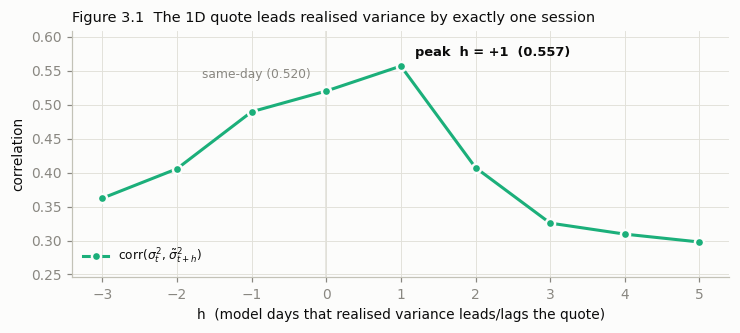

peak at h = +1


In [9]:
iv_s = panel["iv_sameday"].to_numpy(float); rv_s = panel["rv"].to_numpy(float)
prof = []
for h in range(-3, 6):
    y = np.r_[rv_s[h:], np.full(h, np.nan)] if h >= 0 else np.r_[np.full(-h, np.nan), rv_s[:len(rv_s) + h]]
    ok = np.isfinite(iv_s) & np.isfinite(y)
    prof.append({"h": h, "corr": float(np.corrcoef(iv_s[ok], y[ok])[0, 1]), "n": int(ok.sum())})
prof = pd.DataFrame(prof)
peak = int(prof.loc[prof["corr"].idxmax(), "h"])
display(Markdown(r"**Table 3.1 — lead–lag profile $\text{corr}(\sigma^2_t,\ \tilde\sigma^2_{t+h})$**"))
display(prof.style.hide(axis="index").format({"corr": "{:+.4f}"}))

fig, ax = plt.subplots(figsize=(6.8, 3.1))
ax.plot(prof.h, prof["corr"], lw=2, color=SERIES["iv"], marker="o", ms=6,
        mfc=SERIES["iv"], mec="#fcfcfb", mew=1.6, zorder=3, label=r"corr($\sigma^2_t$, $\tilde\sigma^2_{t+h}$)")
pk = prof[prof.h == peak].iloc[0]
ax.annotate(f"peak  h = {peak:+d}  ({pk['corr']:.3f})", (peak, pk["corr"]), textcoords="offset points",
            xytext=(9, 7), fontsize=8.5, color=INK, fontweight="bold", ha="left")
z = prof[prof.h == 0].iloc[0]
ax.annotate(f"same-day ({z['corr']:.3f})", (0, z["corr"]), textcoords="offset points",
            xytext=(-10, 9), fontsize=8, color=MUTED, ha="right")
ax.axvline(0, color=GRID, lw=1, zorder=1)
ax.set_xlabel("h  (model days that realised variance leads/lags the quote)")
ax.set_ylabel("correlation"); ax.set_xticks(range(-3, 6)); ax.margins(y=0.20)
ax.legend(frameon=False, fontsize=8, loc="lower left")
ax.set_title("Figure 3.1  The 1D quote leads realised variance by exactly one session", loc="left", fontsize=9.5)
plt.tight_layout(); plt.show()
print(f"peak at h = {peak:+d}")

**The profile peaks cleanly at $h=+1$** (corr $0.557$) and falls away on both sides, with the
same-day pairing at $h=0$ materially lower (corr $0.520$). Today's 1D ATM quote describes
*tomorrow's* session better than today's. This is the theoretically expected result for an
overnight instrument — but it is now an empirical finding rather than an assumption, which is
what the frozen decisions required.

We nevertheless carry **both** alignments through the full battery, as specified, and settle
the question formally in §7.

---
# 4. Granger causality

## 4.1 Why *conditional* Granger

For each ordered pair (source $X$, target $Y$) we let $Z$ be the remaining third state and fit

$$\text{unrestricted:}\quad Y_t = c + \sum_{j=1}^{p} a_j Y_{t-j} + \sum_{j=1}^{p} b_j X_{t-j} + \sum_{j=1}^{p} g_j Z_{t-j} + u_t$$
$$\text{restricted:}\quad\ \ Y_t = c + \sum_{j=1}^{p} a_j Y_{t-j} + \sum_{j=1}^{p} g_j Z_{t-j} + u_t$$

testing $H_0: b_1=\dots=b_p=0$ with the classical nested $F$ statistic
$F = \frac{(\text{RSS}_R-\text{RSS}_U)/p}{\text{RSS}_U/\text{df}_U}$, and reporting the partial
$R^2 = (\text{RSS}_R-\text{RSS}_U)/\text{RSS}_R$ as the effect size.

Conditioning on $Z$ is not optional here. All three states are strongly co-moving, so a
*bivariate* test would credit $\tilde\sigma^2 \to \sigma^2$ for predictive content that is
really coming from $r^2$ driving both. More importantly, conditional GC is the test that
**matches the question**: equations (2)–(3) put all three lag blocks in the same regression, so
"should block $X$ be in equation for $Y$?" is by construction a test of the $X$ block *given*
the other two.

## 4.2 Effect size is reported alongside significance, deliberately

With ~5,000 observations, statistical significance is cheap. A block can clear $p<10^{-10}$ and
still remove a tenth of a percent of residual variance. The partial $R^2$ column is what
decides whether a term is worth carrying into equations (2)–(3), and §8 uses both.

In [10]:
def lagmat(x: np.ndarray, p: int) -> np.ndarray:
    return np.column_stack([np.r_[np.full(j, np.nan), x[:len(x) - j]] for j in range(1, p + 1)])

def ols_rss(y: np.ndarray, X: np.ndarray):
    XX = np.column_stack([np.ones(len(y)), X])
    beta, *_ = np.linalg.lstsq(XX, y, rcond=None)
    resid = y - XX @ beta
    return float(resid @ resid), XX.shape[1]

def granger(frame: pd.DataFrame, src: str, tgt: str, ctl: str, p: int) -> dict:
    Y  = frame[tgt].to_numpy(float)
    Ly, Lx, Lz = lagmat(Y, p), lagmat(frame[src].to_numpy(float), p), lagmat(frame[ctl].to_numpy(float), p)
    ok = (window_ok(frame.model_day, p) & np.isfinite(Y)
          & np.isfinite(Ly).all(1) & np.isfinite(Lx).all(1) & np.isfinite(Lz).all(1))
    y, n = Y[ok], int(ok.sum())
    rss_u, k_u = ols_rss(y, np.column_stack([Ly[ok], Lx[ok], Lz[ok]]))
    rss_r, _   = ols_rss(y, np.column_stack([Ly[ok], Lz[ok]]))
    df_u = n - k_u
    F = ((rss_r - rss_u) / p) / (rss_u / df_u)
    return {"source": PLAIN[src], "target": PLAIN[tgt], "conditioned_on": PLAIN[ctl], "lag": p,
            "n_obs": n, "F_stat": F, "df_num": p, "df_den": df_u,
            "p_value": float(stats.f.sf(F, p, df_u)), "partial_R2": (rss_r - rss_u) / rss_r}

DIRECTIONS = [(s, t) for s in STATES for t in STATES if s != t]
gc_rows = []
for alignment in ("sameday", "nextday"):
    fr = make_frame(alignment)
    for p in LAGS:
        block = [granger(fr, s, t, next(c for c in STATES if c not in (s, t)), p) for s, t in DIRECTIONS]
        for r in block: r["alignment"] = alignment
        gc_rows += block
gc = pd.DataFrame(gc_rows)
print(f"{len(gc)} Granger tests: {len(DIRECTIONS)} directions x {len(LAGS)} lag orders x 2 alignments")

24 Granger tests: 6 directions x 2 lag orders x 2 alignments


---
# 5. The lag orders, chosen by hand

The spec rules out an AIC/BIC search, so the two orders are argued for directly.

**$p=1$ — one model day.** This is the *native* horizon of the system. The instrument is a 1D
quote, the session is one model day, and the mechanism of interest — today's move informs
tomorrow's vol, today's quote forecasts tomorrow's realised variance — is a one-step
transmission. If an arrow exists at all, it should show at lag 1.

**$p=5$ — one trading week.** The standard weekly block in the realised-volatility literature
(the middle component of HAR), long enough to capture the slower mean-reverting component of
volatility that a one-day lag misses, and to expose any weekly quoting cycle. Five model days
is exactly one week on our calendar, since weekends collapse to a single Friday→Monday lag.

**Why not longer.** Parsimony and scope. Every extra lag costs three regressors under
conditional GC, and Step 1's job is to decide which *blocks* belong in equations (2)–(3), not to
resolve a lag profile — that is what the spec rules out by excluding an AIC/BIC search.

A note on sample cost, since it changed materially: the contiguity guard is multiplicative, so
requiring $p+1$ consecutive clean rows used to be expensive. On the session-aware panel it is
**much cheaper** — ~5,300 usable rows at $p=1$ against ~4,800 at $p=5$, where the earlier
raw-column build lost roughly 40% of the sample going from $p=1$ to $p=5$. Removing the weekend
pseudo-sessions (§1.3) repaired the calendar contiguity they were breaking. Lag 5 is therefore
now well-powered, and the case for stopping there rests on parsimony rather than on data loss.

**What the orders are not.** $p$ is a *history length*, not a causal delay. A significant lag-5
block does not mean "the effect takes five days"; it means the five-day history block carries
incremental predictive content.

---
# 6. Time-delayed mutual information

## 6.1 What TDMI adds

Granger causality only sees **linear** predictive content. Volatility transmission is a
plausibly nonlinear, asymmetric business (leverage effects, jump clustering), so a linear test
could miss a real arrow. TDMI is the nonlinear cross-check:

$$I(X;Y) = \sum_{x,y} p(x,y)\,\log\frac{p(x,y)}{p(x)p(y)}$$

evaluated as $I\big(X_{t-k};\ \tilde Y_t\big)$ — source strictly before target, so the
construction supplies the lead–lag direction that MI, being symmetric, cannot.

## 6.2 Three methodological choices

**AR(1)-residualisation of the target.** Raw MI between two persistent series is dominated by
their own autocorrelation: $\tilde\sigma^2_{t-1}$ and $\tilde\sigma^2_t$ are highly dependent
regardless of any cross-series effect. We therefore fit $Y_t = a + bY_{t-1}$ and take
$I(X_{t-k}, \hat u_t)$ on the residual. This is the information-theoretic counterpart of the
own-lag block in the Granger regression, and it is what makes TDMI a comparable test rather
than a persistence detector.

**Quantile binning, 10 bins per variable.** Variance series are extremely right-skewed;
equal-width bins would put almost every observation in one cell. Quantile bins are
scale- and monotone-transform-invariant, so this also removes the annualised-vs-per-session
units mismatch noted in §1.4.

**Circular-shift surrogates, not independent shuffles.** The null must be "no *cross-series*
dependence", not "no structure at all". Shuffling the source destroys its autocorrelation and
produces a null that is far too easy to beat, inflating significance. A circular shift
preserves the source's serial structure while destroying its alignment to the target. With
$B=1000$ surrogates the one-sided $p$-value is
$p = \frac{1 + \#\{I^{\text{null}} \ge I^{\text{obs}}\}}{1 + B}$, floored at $1/1001 \approx 0.001$.

We also report **TDMI excess** = observed MI − mean surrogate MI. Binned MI is biased upward by
roughly $(n_x-1)(n_y-1)/2n$; the excess subtracts that bias off empirically and is the
effect-size measure we actually compare across directions.

In [11]:
def quantile_codes(x: np.ndarray, bins: int) -> np.ndarray:
    cuts = np.unique(np.quantile(x[np.isfinite(x)], np.linspace(0, 1, bins + 1)[1:-1]))
    if len(cuts) < 1: raise ValueError("degenerate series: cannot form quantile bins")
    return np.digitize(x, cuts, right=True)

def mi_codes(xb: np.ndarray, yb: np.ndarray) -> float:
    nx, ny = xb.max() + 1, yb.max() + 1
    c = np.bincount(xb * ny + yb, minlength=nx * ny).reshape(nx, ny).astype(float)
    j = c / c.sum()
    prod = j.sum(1, keepdims=True) @ j.sum(0, keepdims=True)
    nz = j > 0
    return float(np.sum(j[nz] * np.log(j[nz] / prod[nz])))

def tdmi(frame: pd.DataFrame, src: str, tgt: str, k: int, rng) -> dict:
    Y, X = frame[tgt].to_numpy(float), frame[src].to_numpy(float)
    Y1 = lagmat(Y, 1)[:, 0]

    # AR(1)-residualise the target: strips own-persistence so MI measures cross-series content
    ok_ar = window_ok(frame.model_day, 1) & np.isfinite(Y) & np.isfinite(Y1)
    A = np.column_stack([np.ones(int(ok_ar.sum())), Y1[ok_ar]])
    beta, *_ = np.linalg.lstsq(A, Y[ok_ar], rcond=None)
    resid = np.full(len(Y), np.nan); resid[ok_ar] = Y[ok_ar] - A @ beta

    Xk = np.r_[np.full(k, np.nan), X[:len(X) - k]]                     # source strictly at t-k
    ok = window_ok(frame.model_day, max(k, 1)) & np.isfinite(resid) & np.isfinite(Xk)
    xb, yb = quantile_codes(Xk[ok], BINS), quantile_codes(resid[ok], BINS)
    obs, n = mi_codes(xb, yb), int(ok.sum())

    lo, hi = k + 1, max(k + 2, n - k)                                   # circular shifts, never near-identity
    null = np.array([mi_codes(np.roll(xb, int(s)), yb) for s in rng.integers(lo, hi, size=N_PERM)])
    return {"source": PLAIN[src], "target": PLAIN[tgt], "lag": k, "n_obs": n,
            "TDMI": obs, "null_mean": float(null.mean()), "TDMI_excess": obs - float(null.mean()),
            "p_value": float((1 + np.sum(null >= obs)) / (1 + N_PERM))}

td_rows = []
for alignment in ("sameday", "nextday"):
    fr = make_frame(alignment)
    for p in LAGS:
        block = [tdmi(fr, s, t, p, rng) for s, t in DIRECTIONS]
        for r in block: r["alignment"] = alignment
        td_rows += block
td = pd.DataFrame(td_rows)
print(f"{len(td)} TDMI tests x {N_PERM} surrogates each")

24 TDMI tests x 1000 surrogates each


## 6.3 Multiple-testing correction

Six directions are tested per (alignment, lag) family. Testing six hypotheses at $\alpha=0.05$
gives a ~26% chance of at least one false positive, so we apply **Benjamini–Hochberg FDR**
within each family, controlling the expected proportion of false discoveries among the arrows
we retain.

BH rather than Holm/Bonferroni: this is a *structure-discovery* step feeding a modelling
decision, not a confirmatory test of a single pre-registered hypothesis. The cost of wrongly
dropping a real term from equation (2) exceeds the cost of carrying one spurious term into
Step 2, where it will be re-estimated and can be pruned on out-of-sample performance. FDR is
the correction matched to that asymmetry.

In [12]:
def apply_bh(df: pd.DataFrame) -> pd.DataFrame:
    out = []
    for (_, _), grp in df.groupby(["alignment", "lag"], sort=False):
        grp = grp.copy()
        rej, q, _, _ = multipletests(grp.p_value.to_numpy(), alpha=ALPHA, method="fdr_bh")
        grp["q_value_BH"], grp["significant"] = q, rej
        out.append(grp)
    return pd.concat(out).reset_index(drop=True)

gc, td = apply_bh(gc), apply_bh(td)
gc.to_csv(OUT_DIR / "step1_granger.csv", index=False)
td.to_csv(OUT_DIR / "step1_tdmi.csv", index=False)

def arrow_col(d): return d.source + " -> " + d.target

for alignment in ("sameday", "nextday"):
    display(Markdown(f"**Table 6.1 — conditional Granger causality, *{alignment}* alignment** "
                     f"(BH-FDR within each lag family, α={ALPHA})"))
    v = gc[gc.alignment == alignment].copy(); v.insert(0, "direction", arrow_col(v))
    display(v[["direction", "conditioned_on", "lag", "n_obs", "F_stat", "p_value", "q_value_BH",
               "partial_R2", "significant"]]
            .style.hide(axis="index")
            .format({"F_stat": "{:.4g}", "p_value": "{:.3g}", "q_value_BH": "{:.3g}", "partial_R2": "{:.4f}"}))

**Table 6.1 — conditional Granger causality, *sameday* alignment** (BH-FDR within each lag family, α=0.05)

direction,conditioned_on,lag,n_obs,F_stat,p_value,q_value_BH,partial_R2,significant
r2 -> rv,iv_var,1,5376,14.14,0.000172,0.000206,0.0026,True
r2 -> iv_var,rv,1,5259,27.78,1.41e-07,2.12e-07,0.0053,True
rv -> r2,iv_var,1,5376,0.2373,0.626,0.626,0.0000,False
rv -> iv_var,r2,1,5259,157.8,1.11e-35,2.22e-35,0.0292,True
iv_var -> r2,rv,1,5376,1445,3.53e-280,2.12e-279,0.2119,True
iv_var -> rv,r2,1,5376,1420,5.37e-276,1.61e-275,0.2091,True
r2 -> rv,iv_var,5,4777,2.554,0.0257,0.0309,0.0027,True
r2 -> iv_var,rv,5,4814,1.52,0.18,0.18,0.0016,False
rv -> r2,iv_var,5,4777,3.344,0.00511,0.00766,0.0035,True
rv -> iv_var,r2,5,4814,17.46,3.56e-17,7.12e-17,0.0179,True


**Table 6.1 — conditional Granger causality, *nextday* alignment** (BH-FDR within each lag family, α=0.05)

direction,conditioned_on,lag,n_obs,F_stat,p_value,q_value_BH,partial_R2,significant
r2 -> rv,iv_var,1,5375,0.5932,0.441,0.441,0.0001,False
r2 -> iv_var,rv,1,5261,21.71,3.24e-06,3.89e-06,0.0041,True
rv -> r2,iv_var,1,5375,101.7,1.05e-23,1.57e-23,0.0186,True
rv -> iv_var,r2,1,5261,384.5,1.1e-82,6.61e-82,0.0682,True
iv_var -> r2,rv,1,5375,153.5,8.97e-35,1.79e-34,0.0278,True
iv_var -> rv,r2,1,5375,367.4,2.85e-79,8.54e-79,0.0640,True
r2 -> rv,iv_var,5,4775,3.313,0.00545,0.00655,0.0035,True
r2 -> iv_var,rv,5,4814,1.165,0.324,0.324,0.0012,False
rv -> r2,iv_var,5,4775,25.34,2.64e-25,5.27e-25,0.0259,True
rv -> iv_var,r2,5,4814,72.74,1.25e-73,7.52e-73,0.0705,True


In [13]:
for alignment in ("sameday", "nextday"):
    display(Markdown(f"**Table 6.2 — TDMI, *{alignment}* alignment** "
                     f"(AR(1)-residualised target, {BINS} quantile bins, {N_PERM} circular-shift surrogates, BH-FDR)"))
    v = td[td.alignment == alignment].copy(); v.insert(0, "direction", arrow_col(v))
    display(v[["direction", "lag", "n_obs", "TDMI", "null_mean", "TDMI_excess",
               "p_value", "q_value_BH", "significant"]]
            .style.hide(axis="index")
            .format({"TDMI": "{:.4f}", "null_mean": "{:.4f}", "TDMI_excess": "{:.4f}",
                     "p_value": "{:.3g}", "q_value_BH": "{:.3g}"}))

**Table 6.2 — TDMI, *sameday* alignment** (AR(1)-residualised target, 10 quantile bins, 1000 circular-shift surrogates, BH-FDR)

direction,lag,n_obs,TDMI,null_mean,TDMI_excess,p_value,q_value_BH,significant
r2 -> rv,1,5690,0.0435,0.0079,0.0356,0.000999,0.000999,True
r2 -> iv_var,1,5259,0.0485,0.0094,0.0390,0.000999,0.000999,True
rv -> r2,1,5690,0.0947,0.0084,0.0862,0.000999,0.000999,True
rv -> iv_var,1,5259,0.1578,0.0155,0.1423,0.000999,0.000999,True
iv_var -> r2,1,5376,0.0923,0.0102,0.0821,0.000999,0.000999,True
iv_var -> rv,1,5376,0.1746,0.0144,0.1602,0.000999,0.000999,True
r2 -> rv,5,5610,0.0276,0.0079,0.0197,0.000999,0.002,True
r2 -> iv_var,5,5255,0.0372,0.0092,0.0279,0.002,0.003,True
rv -> r2,5,5610,0.0447,0.0085,0.0362,0.000999,0.002,True
rv -> iv_var,5,5255,0.1145,0.0148,0.0997,0.000999,0.002,True


**Table 6.2 — TDMI, *nextday* alignment** (AR(1)-residualised target, 10 quantile bins, 1000 circular-shift surrogates, BH-FDR)

direction,lag,n_obs,TDMI,null_mean,TDMI_excess,p_value,q_value_BH,significant
r2 -> rv,1,5690,0.0435,0.0078,0.0357,0.000999,0.0015,True
r2 -> iv_var,1,5261,0.0684,0.0094,0.0591,0.000999,0.0015,True
rv -> r2,1,5690,0.0947,0.0084,0.0863,0.000999,0.0015,True
rv -> iv_var,1,5261,0.1980,0.0149,0.1831,0.000999,0.0015,True
iv_var -> r2,1,5375,0.0697,0.0101,0.0596,0.002,0.0024,True
iv_var -> rv,1,5375,0.1088,0.0136,0.0952,0.003,0.003,True
r2 -> rv,5,5610,0.0276,0.0079,0.0197,0.000999,0.002,True
r2 -> iv_var,5,5254,0.0410,0.0093,0.0317,0.000999,0.002,True
rv -> r2,5,5610,0.0447,0.0087,0.0360,0.004,0.004,True
rv -> iv_var,5,5254,0.1290,0.0155,0.1134,0.002,0.003,True


---
# 7. Synthesis and the alignment decision

## 7.1 The combined table

An arrow is **retained** only if it survives BH-FDR under *both* Granger and TDMI, in the same
alignment and lag family.

In [14]:
merged = gc.merge(td, on=["alignment", "lag", "source", "target"], suffixes=("_gc", "_tdmi"))
merged["retained"] = merged.significant_gc & merged.significant_tdmi
merged.insert(0, "direction", arrow_col(merged))
merged.to_csv(OUT_DIR / "step1_combined.csv", index=False)

display(Markdown("**Table 7.1 — combined verdict, both alignments side by side**"))
view = (merged.pivot_table(index=["direction", "lag"], columns="alignment",
                           values=["partial_R2", "TDMI_excess", "retained"], aggfunc="first")
        .reorder_levels([1, 0], axis=1).sort_index(axis=1))
display(view.style.format({c: "{:.4f}" for c in view.columns if c[1] != "retained"}))

display(Markdown("**Retained arrows by alignment and lag**"))
for alignment in ("sameday", "nextday"):
    for p in LAGS:
        sub = merged[(merged.alignment == alignment) & (merged.lag == p) & merged.retained]
        print(f"  {alignment:8s} lag {p}: " + (", ".join(sub.direction) if len(sub) else "(none)"))

**Table 7.1 — combined verdict, both alignments side by side**

**Retained arrows by alignment and lag**

  sameday  lag 1: r2 -> rv, r2 -> iv_var, rv -> iv_var, iv_var -> r2, iv_var -> rv
  sameday  lag 5: r2 -> rv, rv -> r2, rv -> iv_var, iv_var -> r2, iv_var -> rv
  nextday  lag 1: r2 -> iv_var, rv -> r2, rv -> iv_var, iv_var -> r2, iv_var -> rv
  nextday  lag 5: r2 -> rv, rv -> r2, rv -> iv_var, iv_var -> r2, iv_var -> rv


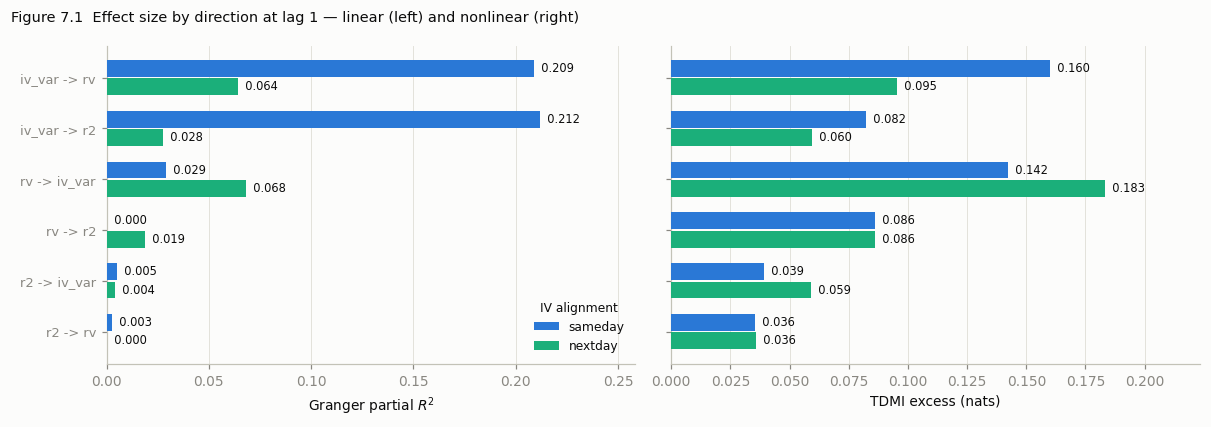

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
for ax, (metric, lab) in zip(axes, [("partial_R2", "Granger partial $R^2$"), ("TDMI_excess", "TDMI excess (nats)")]):
    dirs = list(dict.fromkeys(merged.direction))
    y = np.arange(len(dirs)); h = 0.36
    for off, alignment, colour in [(+h/2, "sameday", SERIES["r2"]), (-h/2, "nextday", SERIES["iv"])]:
        vals = [merged[(merged.alignment == alignment) & (merged.lag == 1) & (merged.direction == d)][metric].iloc[0] for d in dirs]
        ax.barh(y + off, vals, height=h - 0.03, color=colour, label=alignment, zorder=3)
        for yy, v in zip(y + off, vals):
            ax.text(v, yy, f"  {v:.3f}", va="center", fontsize=7.5, color=INK)
    ax.set_yticks(y); ax.set_yticklabels(dirs, fontsize=8.5)
    ax.set_xlabel(lab); ax.grid(axis="y", visible=False); ax.margins(x=0.22)
axes[0].legend(frameon=False, fontsize=8, loc="lower right", title="IV alignment", title_fontsize=8)
fig.suptitle("Figure 7.1  Effect size by direction at lag 1 — linear (left) and nonlinear (right)",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

## 7.2 Same-day versus next-day: which is primary

**A trap to avoid first.** It is tempting to pick the alignment with the bigger $F$-statistics —
and the same-day columns *are* larger (e.g. iv → rv at lag 1: $F=1420$, partial $R^2=0.209$,
against $F=367$, partial $R^2=0.064$ next-day). **That comparison is invalid.** The two
alignments place the IV column one row apart, so a lag-1 test under same-day uses
$\sigma^2_{t-1}$ while the same test under next-day uses $\sigma^2_{t-2}$. The next-day
specification is being asked to predict with a strictly staler quote, so of course it looks
weaker. Raw $F$ magnitude measures *predictor freshness here, not alignment correctness*.

The valid comparison is the row-contemporaneous one from §3, which holds the information lag
fixed and asks only which $\tilde\sigma^2$ a given quote belongs with:

| pairing | correlation |
|---|---|
| $\sigma^2_t$ with $\tilde\sigma^2_t$ (same-day) | 0.520 |
| $\sigma^2_t$ with $\tilde\sigma^2_{t+1}$ (next-day) | **0.557** |

Three findings converge on next-day:

1. **The lead–lag profile peaks at $h=+1$** and is single-peaked, with $h=0$ clearly below it
   (Figure 3.1). This is the direct, model-free answer.
2. **Next-day is information-consistent.** Under it, the IV in a row is a quote *observed
   before* the session whose realised variance sits in the same row. Every row is a genuine
   ex-ante forecast paired with its outcome. Under same-day, the quote and the session it is
   paired with overlap in time, so a row mixes a forecast with the thing being forecast — which
   would quietly contaminate Step 2's calibration and Step 3's event-weight estimates.
3. **It matches the instrument.** `USDJPYVON` is an *overnight* contract: quoted on day $t$, it
   prices the move to $t+1$. Alignment (b) is what the contract's own definition asserts.

The structural conclusions are, reassuringly, **not sensitive to the choice** — the
$r^2 \to \sigma^2$, $\tilde\sigma^2 \to \sigma^2$, $\sigma^2 \to \tilde\sigma^2$ and
$\sigma^2 \to r^2$ arrows are retained under both alignments at lag 1. The alignment matters
for coefficient magnitudes, not for which arrows exist. The one direction that flips —
$\tilde\sigma^2 \to r^2$, retained next-day and rejected same-day — is discussed in §8.

> ### Decision
> **The next-day alignment ($\sigma_t^2$ paired with $\tilde\sigma_{t+1}^2$) is adopted as the
> primary specification for Steps 2 onward.** Justification: the $h=+1$ cross-correlation peak,
> information-consistency of each row, and the overnight definition of the instrument. The
> same-day results are retained in `step1_results/` as a robustness benchmark.

## 7.3 How to read the TDMI column

Every one of the 24 TDMI tests is significant after FDR. That is not a bug and not a rubber
stamp — the excess-MI magnitudes vary by nearly an order of magnitude across directions
(0.020 to 0.183 nats) — but it does mean TDMI is **not the discriminating instrument here**. At
$n \approx 4{,}800$–5,400 with 10×10 bins, MI has enough power to detect the pervasive
dependence that links any two volatility-related series.

So the division of labour is: **Granger discriminates, TDMI confirms**. Conditional GC is the
sharper test because it conditions on the third state *and* on the target's own history, and it
is what actually separates the six directions. TDMI's role is the one it was brought in for —
verifying that no arrow GC rejects is being missed because the relationship is nonlinear rather
than absent. It rejects nothing that GC retains, so no nonlinear-only arrow was found. The
ranking by TDMI excess is nonetheless informative and agrees with the GC partial $R^2$ ranking:
the $\sigma^2 \leftrightarrow \tilde\sigma^2$ pair dominates.

---
# 8. The causal structure, and the modified equations

## 8.1 Structure found

Under the adopted **next-day** alignment at **lag 1**, five of six directions are retained by
Granger and all six by TDMI, giving five retained arrows:

```
                r²  ──────────────►  σ²          (partial R² 0.0041)
                r²  ──X──            σ̃²          rejected: p = 0.44
                σ̃²  ──────────────►  σ²          (partial R² 0.0682)
                σ̃²  ──────────────►  r²          (partial R² 0.0186)
                σ²  ──────────────►  σ̃²          (partial R² 0.0640)
                σ²  ──────────────►  r²          (partial R² 0.0278)
```

Reading it substantively:

- **The volatility pair is bidirectional and dominant.** $\sigma^2 \leftrightarrow \tilde\sigma^2$
  carries by far the largest effect sizes in both tests. The implied–realised relationship is a
  genuine feedback loop, not a one-way forecast: the market's quote predicts realised variance
  *and* realised variance predicts the next quote. This is exactly the coupled structure
  equations (2)–(3) were written to accommodate, and it is the single most important finding
  for the rest of the dissertation.
- **$r^2 \to \tilde\sigma^2$ does not survive** ($p=0.44$ at lag 1; it does re-enter weakly at
  lag 5, $p=0.005$, partial $R^2$ 0.003). The natural reading is that $r^2$ is a **noisy,
  redundant proxy** for information already in $\tilde\sigma^2$: a single squared daily return
  is a one-observation variance estimate, whereas $\tilde\sigma^2$ aggregates 24 intraday
  squares. Once the far more efficient estimator's own lag is in the regression, the crude one
  adds nothing. This is a redundancy result, not evidence that return magnitude is
  irrelevant to volatility.
- **$r^2 \to \sigma^2$ *does* survive**, though weakly (partial $R^2$ 0.0041). Quoted vol
  responds to the headline daily move in a way that realised variance does not — consistent with
  option market-makers marking to a salient price move.
- **$\tilde\sigma^2 \to r^2$ is retained under next-day but rejected same-day.** We treat this
  as the weakest of the five. Given the $r^2$ redundancy result above and the alignment
  sensitivity, it should not be leaned on; it is flagged in §9.

## 8.2 Equations (2) and (3), restricted to the discovered structure

Linus's equations carry all three lag blocks in both variance equations. The Step 1 evidence
supports **dropping the $r^2$ block from the realised-variance equation and retaining
everything else**. With $n = m = 1$ as the primary specification:

**Equation (2) — realised variance.** The $\tilde\alpha_j r^2_{i-j}$ block is removed:

$$\boxed{\ \tilde\sigma_i^2 \;=\; \tilde\phi_i \;+\; \tilde\beta_1\,\tilde\sigma_{i-1}^2 \;+\; \tilde\gamma_1\,\sigma_{i-1}^2 \;+\; \tilde\nu_i\eta_i\ }$$

i.e. $\tilde\alpha_j \equiv 0$. Realised variance is driven by its own persistence and by the
implied-variance state, with squared returns contributing nothing incremental.

**Equation (3) — implied variance.** All three blocks survive; the equation stands as written:

$$\boxed{\ \sigma_i^2 \;=\; \phi_i \;+\; \alpha_1 r_{i-1}^2 \;+\; \beta_1\,\tilde\sigma_{i-1}^2 \;+\; \gamma_1\,\sigma_{i-1}^2 \;+\; \nu_i\zeta_i\ }$$

**Equation (1) — the return equation.** Unchanged. The two retained arrows into $r^2$ concern
return *magnitude*, which equation (1) already carries through $\tilde\sigma_i$; they are not
evidence for a conditional-mean term. Adding an AR component to $\mu_i$ is not supported by
anything tested here, and (1) is an observation equation rather than a dynamic one.

Here $\sigma^2_{i-1}$ stands in for Linus's $\sigma^2_{i|i-j}$ per the single-tenor
approximation of §0, and — under the adopted next-day alignment — $\sigma^2_{i-1}$ is the quote
observed on the model day preceding session $i$, so every regressor is in the information set
at the start of session $i$.

**A note on the lag-5 specification.** At $p=5$ (next-day) the retained set is
$r^2 \to \tilde\sigma^2$, $\tilde\sigma^2 \to r^2$, $\tilde\sigma^2 \to \sigma^2$,
$\sigma^2 \to \tilde\sigma^2$, $\sigma^2 \to r^2$ — the same five arrows as lag 1 except that
$r^2 \to \tilde\sigma^2$ replaces $r^2 \to \sigma^2$. The weekly block therefore re-admits
$r^2 \to \tilde\sigma^2$, but the effect is small (partial $R^2$ 0.003) and, per §1.5, a
five-day block involving `iv_var` is confounded with the Friday quoting cycle. We therefore take
**$n=m=1$ as primary** and treat $p=5$ as a robustness check, revisited in Step 2 where
out-of-sample forecast accuracy can adjudicate.

In [16]:
primary = merged[(merged.alignment == "nextday") & (merged.lag == 1)][
    ["direction", "partial_R2", "p_value_gc", "q_value_BH_gc", "TDMI_excess", "q_value_BH_tdmi", "retained"]]
display(Markdown("**Table 8.1 — the adopted primary specification: next-day alignment, lag 1**"))
display(primary.sort_values("partial_R2", ascending=False).style.hide(axis="index")
        .format({"partial_R2": "{:.4f}", "p_value_gc": "{:.3g}", "q_value_BH_gc": "{:.3g}",
                 "TDMI_excess": "{:.4f}", "q_value_BH_tdmi": "{:.3g}"}))

structure = {
    "adopted_alignment": "nextday",
    "adopted_lag_order": 1,
    "alignment_evidence": {"xcorr_peak_h": int(peak),
                           "corr_sameday": float(prof[prof.h == 0]["corr"].iloc[0]),
                           "corr_nextday": float(prof[prof.h == 1]["corr"].iloc[0])},
    "retained_arrows": sorted(primary[primary.retained].direction),
    "rejected_arrows": sorted(primary[~primary.retained].direction),
    "eq2_blocks_retained": ["rv_lag", "iv_lag"],
    "eq2_blocks_dropped":  ["r2_lag"],
    "eq3_blocks_retained": ["r2_lag", "rv_lag", "iv_lag"],
}
(OUT_DIR / "step1_structure.json").write_text(json.dumps(structure, indent=2))
print(json.dumps(structure, indent=2))
print("\nwritten to", OUT_DIR.resolve())

**Table 8.1 — the adopted primary specification: next-day alignment, lag 1**

direction,partial_R2,p_value_gc,q_value_BH_gc,TDMI_excess,q_value_BH_tdmi,retained
rv -> iv_var,0.0682,1.1e-82,6.61e-82,0.1831,0.0015,True
iv_var -> rv,0.0640,2.85e-79,8.54e-79,0.0952,0.003,True
iv_var -> r2,0.0278,8.97e-35,1.79e-34,0.0596,0.0024,True
rv -> r2,0.0186,1.05e-23,1.57e-23,0.0863,0.0015,True
r2 -> iv_var,0.0041,3.24e-06,3.89e-06,0.0591,0.0015,True
r2 -> rv,0.0001,0.441,0.441,0.0357,0.0015,False


{
  "adopted_alignment": "nextday",
  "adopted_lag_order": 1,
  "alignment_evidence": {
    "xcorr_peak_h": 1,
    "corr_sameday": 0.5200346869054563,
    "corr_nextday": 0.5567822465270585
  },
  "retained_arrows": [
    "iv_var -> r2",
    "iv_var -> rv",
    "r2 -> iv_var",
    "rv -> iv_var",
    "rv -> r2"
  ],
  "rejected_arrows": [
    "r2 -> rv"
  ],
  "eq2_blocks_retained": [
    "rv_lag",
    "iv_lag"
  ],
  "eq2_blocks_dropped": [
    "r2_lag"
  ],
  "eq3_blocks_retained": [
    "r2_lag",
    "rv_lag",
    "iv_lag"
  ]
}

written to /Users/aksharaa/Documents/HSBC-AN-RN/CODEWORK/Linus' Task Re-Do/step1_results


---
# 9. Caveats carried forward

1. **Granger ≠ cause.** Every arrow above is conditional linear predictive content over a
   23-year average. No counterfactual or structural claim is made or licensed.
2. **The Friday quoting artifact is uncorrected** (§1.5). Median Friday implied variance is
   ~65% below Thursday's for mechanical calendar-count reasons. Any lag-5 result involving
   `iv_var` is partly a weekday-cycle result. Step 2 should test a weekday-normalised IV as a
   robustness variant now that the structure has been identified on the raw series.
3. **Single tenor.** Linus's $\sigma^2_{i|i-j}$ (his equation 5) needs two points on the term
   structure; we hold only 1D ATM, so lagged $\sigma^2$ substitutes for the conditional forward
   implied variance. Implementing (5) properly requires the multi-tenor surface.
4. **$r^2$ stationarity rests on the full sample.** Its longest-contiguous-run ADF does not
   reject ($p=0.12$, n=264, §2). We attribute this to low power on a short quiet window rather
   than to integration, but the full-sample result is doing the work.
5. **Parameter stability is untested.** ADF rejects a unit root; it says nothing about whether
   the 2008 GFC, Abenomics, and the 2022–24 BoJ shift share one set of coefficients. Step 1
   reports an average structure. Sub-sample stability belongs in Step 2.
6. **$\tilde\sigma^2 \to r^2$ is alignment-sensitive** — retained next-day, rejected same-day —
   and should be treated as provisional.
7. **Mild sample difference across lag orders.** The contiguity guard admits ~4,800 rows at
   $p=5$ against ~5,300 at $p=1$. This is far less severe than on the earlier raw-column build,
   but the two lag families still rest on slightly different samples.
8. **No out-of-sample validation.** Step 1 is full-sample structure identification, so the
   retained arrows are in-sample findings. The whole battery here is a *specification search*
   whose output is a model form; that form gets its genuine test in Step 2's out-of-sample
   forecast evaluation.

## Hand-off to Step 2

`step1_results/` contains `step1_granger.csv`, `step1_tdmi.csv`, `step1_combined.csv`, and
`step1_structure.json`. Step 2 should calibrate the boxed equations of §8.2 — next-day
alignment, $n=m=1$, no $r^2$ block in the realised-variance equation — and measure
out-of-sample forecast accuracy against the unrestricted specification carrying all three
blocks, which is the direct test of whether the restriction found here actually helps.

## Hand-off export: the panel itself

Step 1's existing exports carry the *test results*; they do not carry the *data those tests
ran on*. Step 2 has to calibrate the surviving equations on exactly the sample tested here,
so we additively export the constructed panel. Step 2 loads this file rather than rebuilding
the panel from the raw hourly and ATM inputs, which removes any possibility of the two
notebooks silently drifting apart on model-day construction, RV eligibility, or the
next-day IV shift. Nothing above this cell is modified.

In [17]:
# ---- additive hand-off export: the exact panel Step 1 tested ----------------
export_cols = ["model_day", "r", "r2", "rv", "rv_eligible",
               "iv_var", "iv_sameday", "iv_nextday",
               "n_bars", "n_valid_ret", "complete24", "zero_rv"]
step1_panel = panel[export_cols].copy()

# Carry the contiguity machinery too, so Step 2 inherits the identical lag-window
# guard instead of re-deriving it (MAX_CAL_GAP = 7 model days).
step1_panel["gap_days"]     = panel.model_day.diff().dt.days
step1_panel["contig_break"] = bridges          # True where row t is unreachable from row t-1

# fail loudly rather than export a panel that disagrees with what was tested above
assert len(step1_panel) == len(panel)
assert int(step1_panel.rv_eligible.sum()) == int(panel.rv_eligible.sum())
assert step1_panel.model_day.is_monotonic_increasing and step1_panel.model_day.is_unique

step1_panel.to_csv(OUT_DIR / "step1_panel.csv", index=False)
print(f"step1_panel.csv written: {len(step1_panel):,} model days x {step1_panel.shape[1]} columns")
print(f"  RV-eligible rows        : {int(step1_panel.rv_eligible.sum()):,}")
print(f"  rows with iv_nextday    : {int(step1_panel.iv_nextday.notna().sum()):,}")
print(f"  rows usable for lag-1 fit: "
      f"{int((step1_panel.rv_eligible & step1_panel.iv_nextday.notna()).sum()):,} (before the lag shift)")
print(f"  span                    : {step1_panel.model_day.min().date()} .. {step1_panel.model_day.max().date()}")
print("\nwritten to", (OUT_DIR / "step1_panel.csv").resolve())

step1_panel.csv written: 5,842 model days x 14 columns
  RV-eligible rows        : 5,762
  rows with iv_nextday    : 5,516
  rows usable for lag-1 fit: 5,443 (before the lag shift)
  span                    : 2003-05-05 .. 2026-07-02

written to /Users/aksharaa/Documents/HSBC-AN-RN/CODEWORK/Linus' Task Re-Do/step1_results/step1_panel.csv
